In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q "/content/drive/MyDrive/prescription.zip" -d "/content/dataset/"


In [5]:
import tensorflow as tf
import os

# Check if GPU is active
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Check if folders unzipped correctly
print("Folders found:", os.listdir("/content/dataset/"))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Folders found: ['data', '__huggingface_repos__.json']


In [6]:
import pandas as pd
import os
import json

# 1- defining the basepath where dataset was unzipped
dataset_dir = "/content/dataset/data/processed/"

# 2- load the json files that maps numbers to drug names
json_path = os.path.join(dataset_dir,'mapping.json')

with open(json_path, 'r') as f:
    drug_map = json.load(f)

# printing out the first 5 items to see how it looks
print("---sample of json mapping----")
sample_keys = list(drug_map.keys())[:5]

for key in sample_keys:
  print(f"Number {drug_map[key]} maps to drug: {key}")

print(f"Total Number of Drug Classes in JSON: {len(drug_map)}")

print(drug_map)

---sample of json mapping----
Number 0 maps to drug: Aceta
Number 1 maps to drug: Ace
Number 2 maps to drug: Alatrol
Number 3 maps to drug: Amodis
Number 4 maps to drug: Atrizin
Total Number of Drug Classes in JSON: 78
{'Aceta': 0, 'Ace': 1, 'Alatrol': 2, 'Amodis': 3, 'Atrizin': 4, 'Axodin': 5, 'Azithrocin': 6, 'Azyth': 7, 'Az': 8, 'Bacaid': 9, 'Backtone': 10, 'Baclofen': 11, 'Baclon': 12, 'Bacmax': 13, 'Beklo': 14, 'Bicozin': 15, 'Canazole': 16, 'Candinil': 17, 'Cetisoft': 18, 'Conaz': 19, 'Dancel': 20, 'Denixil': 21, 'Diflu': 22, 'Dinafex': 23, 'Disopan': 24, 'Esonix': 25, 'Esoral': 26, 'Etizin': 27, 'Exium': 28, 'Fenadin': 29, 'Fexofast': 30, 'Fexo': 31, 'Filmet': 32, 'Fixal': 33, 'Flamyd': 34, 'Flexibac': 35, 'Flexilax': 36, 'Flugal': 37, 'Ketocon': 38, 'Ketoral': 39, 'Ketotab': 40, 'Ketozol': 41, 'Leptic': 42, 'Lucan-R': 43, 'Lumona': 44, 'M-Kast': 45, 'Maxima': 46, 'Maxpro': 47, 'Metro': 48, 'Metsina': 49, 'Monas': 50, 'Montair': 51, 'Montene': 52, 'Montex': 53, 'Napa Extend': 54

In [7]:

train_csv_path = os.path.join(dataset_dir, 'train_labels.csv')
test_csv_path = os.path.join(dataset_dir,'test_labels.csv')
val_csv_path = os.path.join(dataset_dir,'val_labels.csv')

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
val_df = pd.read_csv(val_csv_path)

# inspecting the top five rows of the training dataframe
print(train_df.head())

print("\n--Dataset sizes---")
print(f"Training Set Size: {len(train_df)}")
print(f"Test Set Size: {len(test_df)}")
print(f"Validation Set Size: {len(val_df)}")

   IMAGE  MEDICINE_NAME
0  0.png              0
1  1.png              0
2  2.png              0
3  3.png              0
4  4.png              0

--Dataset sizes---
Training Set Size: 3120
Test Set Size: 780
Validation Set Size: 780


In [17]:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_df['MEDICINE_NAME'] = train_df['MEDICINE_NAME'].astype(str)
val_df['MEDICINE_NAME'] = val_df['MEDICINE_NAME'].astype(str)
test_df['MEDICINE_NAME'] = test_df['MEDICINE_NAME'].astype(str)



# Defining the ImageDataGenerator
# this step will automatically rescale the pixel values from [0, 255] to [0.0, 1.0]

train_datagen = ImageDataGenerator(
    rescale=1./255,
    fill_mode='nearest'     # Fills in any empty pixels created by shifting text
)
val_test_datagen = ImageDataGenerator(rescale=1./255)



# creating the TrainingDataGenerator
train_generator = train_datagen.flow_from_dataframe(
    dataframe = train_df,
    directory = "/content/dataset/data/processed/train/images",
    x_col = "IMAGE",
    y_col = "MEDICINE_NAME",
    target_size = (84, 84),
    color_mode ="grayscale",
    class_mode = "categorical",
    batch_size = 32,
    shuffle = True,
)

# creating validation Data Generator
validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe = val_df,
    directory = "/content/dataset/data/processed/val/images",
    x_col = "IMAGE",
    y_col = "MEDICINE_NAME",
    target_size = (84, 84),
    color_mode ="grayscale",
    class_mode = "categorical",
    batch_size = 32,
    shuffle = False,
)

# creating test Data Generator
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe = test_df,
    directory = "/content/dataset/data/processed/test/images",
    x_col = "IMAGE",
    y_col = "MEDICINE_NAME",
    target_size = (84, 84),
    color_mode ="grayscale",
    class_mode = "categorical",
    batch_size = 32,
    shuffle = False,
)


Found 3120 validated image filenames belonging to 78 classes.
Found 780 validated image filenames belonging to 78 classes.
Found 780 validated image filenames belonging to 78 classes.


In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

def build_upscaled_resnet_model(input_shape=(84, 84, 1), num_classes=78):
    inputs = layers.Input(shape=input_shape, name="original_grayscale_input")

    # 1. Dynamically resize images from 84x84 to 224x224 on the GPU
    upscaled_inputs = layers.Resizing(224, 224, interpolation="bilinear", name="spatial_upscaler")(inputs)

    # 2. Bridge 1-channel grayscale to 3-channel RGB
    rgb_inputs = layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x), name="grayscale_to_rgb")(upscaled_inputs)

    # 3. CRITICAL: Rescale your [0, 1] data back to what ResNet expects
    # We multiply by 255.0 to reverse your generator's 1./255 rescaling,
    # then apply ResNet's native ImageNet channel-mean normalization.
    resnet_preprocessed = layers.Lambda(
        lambda x: preprocess_input(x * 255.0),
        name="resnet_preprocess_bridge"
    )(rgb_inputs)

    # 4. Load Pre-trained ResNet50 Base using the correctly preprocessed tensor
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_tensor=resnet_preprocessed,
        pooling='avg'
    )

    base_model.trainable = False

    # 5. Classification Head
    x = base_model.output
    x = layers.Dense(256, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="medicine_predictions")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="ResNet50_Fixed_Pipeline")
    return model

model = build_upscaled_resnet_model()

In [20]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. Re-compile the model explicitly defining the initial learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Set up our new, advanced callbacks array
callbacks = [
    # Pull the emergency brake if no progress is made for 6 epochs
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),

    # Save the absolute champion version using the modern native extension
    ModelCheckpoint('best_prescription_model.keras', monitor='val_loss', save_best_only=True, verbose=1),

    # THE FIX: If val_loss doesn't improve for 2 epochs, cut the learning rate by half (factor=0.5)
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# 3. Train the model again
print("Training with automated learning rate cooling down active...")
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
)

Training with automated learning rate cooling down active...
Epoch 1/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.0248 - loss: 4.7617
Epoch 1: val_loss improved from None to 3.96717, saving model to best_prescription_model.keras

Epoch 1: finished saving model to best_prescription_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - accuracy: 0.0353 - loss: 4.5781 - val_accuracy: 0.1038 - val_loss: 3.9672 - learning_rate: 1.0000e-04
Epoch 2/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.0893 - loss: 3.9943
Epoch 2: val_loss improved from 3.96717 to 3.42359, saving model to best_prescription_model.keras

Epoch 2: finished saving model to best_prescription_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.1064 - loss: 3.8846 - val_accuracy: 0.2513 - val_loss: 3.4236 - learning_rate: 1.0000e-04
Epoch 3/40
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.1750 - loss: 3.4955
Epoch 3: val_loss improved from 3.42359 to 3.04735, saving model to 

In [21]:
# --- STAGE 2: FINE-TUNING THE BACKBONE ---

print("\n--- Starting Stage 2: Fine-Tuning ---")
# 1. Unfreeze the entire base model layers
for layer in model.layers:
    if layer.name == "resnet50":
        layer.trainable = True

        # 2. To prevent breaking what we learned, we only unfreeze the top residual block
        # We keep early layers (conv1, conv2, conv3, conv4) frozen, and unfreeze conv5 blocks
        for sub_layer in layer.layers:
            if "conv5" in sub_layer.name or "block3" in sub_layer.name:
                sub_layer.trainable = True
            else:
                sub_layer.trainable = False

# 3. Re-compile the model with an ULTRA-LOW learning rate (1e-5)
# This prevents destroying the pre-trained features while allowing subtle stroke adaptation
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Update checkpoints for Stage 2
callbacks_stage2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_prescription_resnet_finetuned.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]

# 5. Run fine-tuning for an additional 15-20 epochs
fine_tune_history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks_stage2,
    verbose=1
)


--- Starting Stage 2: Fine-Tuning ---
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.9754 - loss: 0.2996
Epoch 1: val_loss improved from None to 0.97974, saving model to best_prescription_resnet_finetuned.keras

Epoch 1: finished saving model to best_prescription_resnet_finetuned.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 221ms/step - accuracy: 0.9712 - loss: 0.3093 - val_accuracy: 0.7859 - val_loss: 0.9797 - learning_rate: 1.0000e-05
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.9743 - loss: 0.3018
Epoch 2: val_loss improved from 0.97974 to 0.97262, saving model to best_prescription_resnet_finetuned.keras

Epoch 2: finished saving model to best_prescription_resnet_finetuned.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step - accuracy: 0.9721 - loss: 0.2984 - val_accuracy: 0.7846 - val_loss: 0.9726 - learning_rate: 1.0000e-05
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9736 - loss: 0.3104
Epoch 3: val_loss improved from 0.97262 to 0.9

In [25]:
# Evaluate using the model directly from your active session memory
live_loss, live_accuracy = model.evaluate(test_generator)

print("\n--- Live Memory ResNet50 Results ---")
print(f"Test Loss: {live_loss:.4f}")
print(f"Test Accuracy: {live_accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.6321 - loss: 1.7546

--- Live Memory ResNet50 Results ---
Test Loss: 1.7546
Test Accuracy: 63.21%


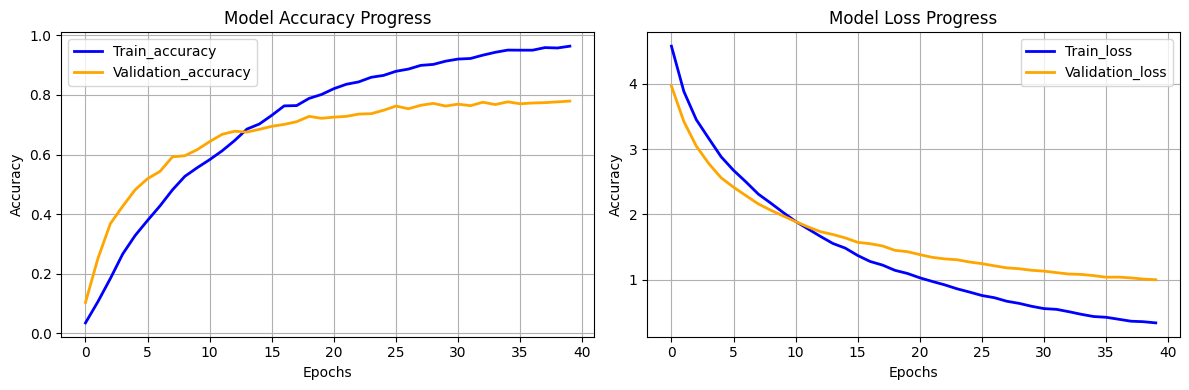

In [26]:
from IPython.core.magics.osm import line_cell_magic
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Plot 1: Accuracy Evolution
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train_accuracy', color='blue', linewidth = 2)
plt.plot(history.history['val_accuracy'], label = 'Validation_accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot 2: Loss Evolution
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label= 'Train_loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation_loss', color='orange', linewidth=2)
plt.title('Model Loss Progress')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
from sklearn.metrics import classification_report

# 1. Invert your mapping dictionary (turn Number -> Name)
# Since your original JSON has Name: Number, this flips it to Number: Name
id_to_medicine = {str(value): key for key, value in drug_map.items()}

# 2. Reset the test generator to ensure it starts from the very first image
test_generator.reset()

# 3. Get predictions (probabilities) from the model
predictions = model.predict(test_generator)

# 4. Convert probabilities to class indices (pick the highest percentage match)
predicted_classes = np.argmax(predictions, axis=1)

# 5. Get the true numeric labels from the generator
true_classes = test_generator.classes

# 6. Map the generator's class indices back to the actual medicine names
# Keras stores the classes as sorted strings, so we map them using our inverted dict
generator_classes = list(test_generator.class_indices.keys())
actual_medicine_names = [id_to_medicine.get(num, f"Unknown_{num}") for num in generator_classes]

# 7. Print the beautiful text evaluation report with actual drug names
print("--- Detailed Classification Report (Actual Medicine Names) ---")
print(classification_report(true_classes, predicted_classes, target_names=actual_medicine_names))

25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 248ms/step
--- Detailed Classification Report (Actual Medicine Names) ---
              precision    recall  f1-score   support

       Aceta       0.83      1.00      0.91        10
         Ace       0.83      0.50      0.62        10
    Backtone       0.62      1.00      0.77        10
    Baclofen       0.60      0.90      0.72        10
      Baclon       1.00      0.80      0.89        10
      Bacmax       1.00      0.80      0.89        10
       Beklo       0.60      0.30      0.40        10
     Bicozin       0.62      0.80      0.70        10
    Canazole       0.40      0.20      0.27        10
    Candinil       0.56      1.00      0.71        10
    Cetisoft       1.00      0.90      0.95        10
       Conaz       0.73      0.80      0.76        10
     Alatrol       0.64      0.70      0.67        10
      Dancel       0.67      0.80      0.73        10
     Denixil       1.00      0.60      0.75        10
       Diflu       0.67      0

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step


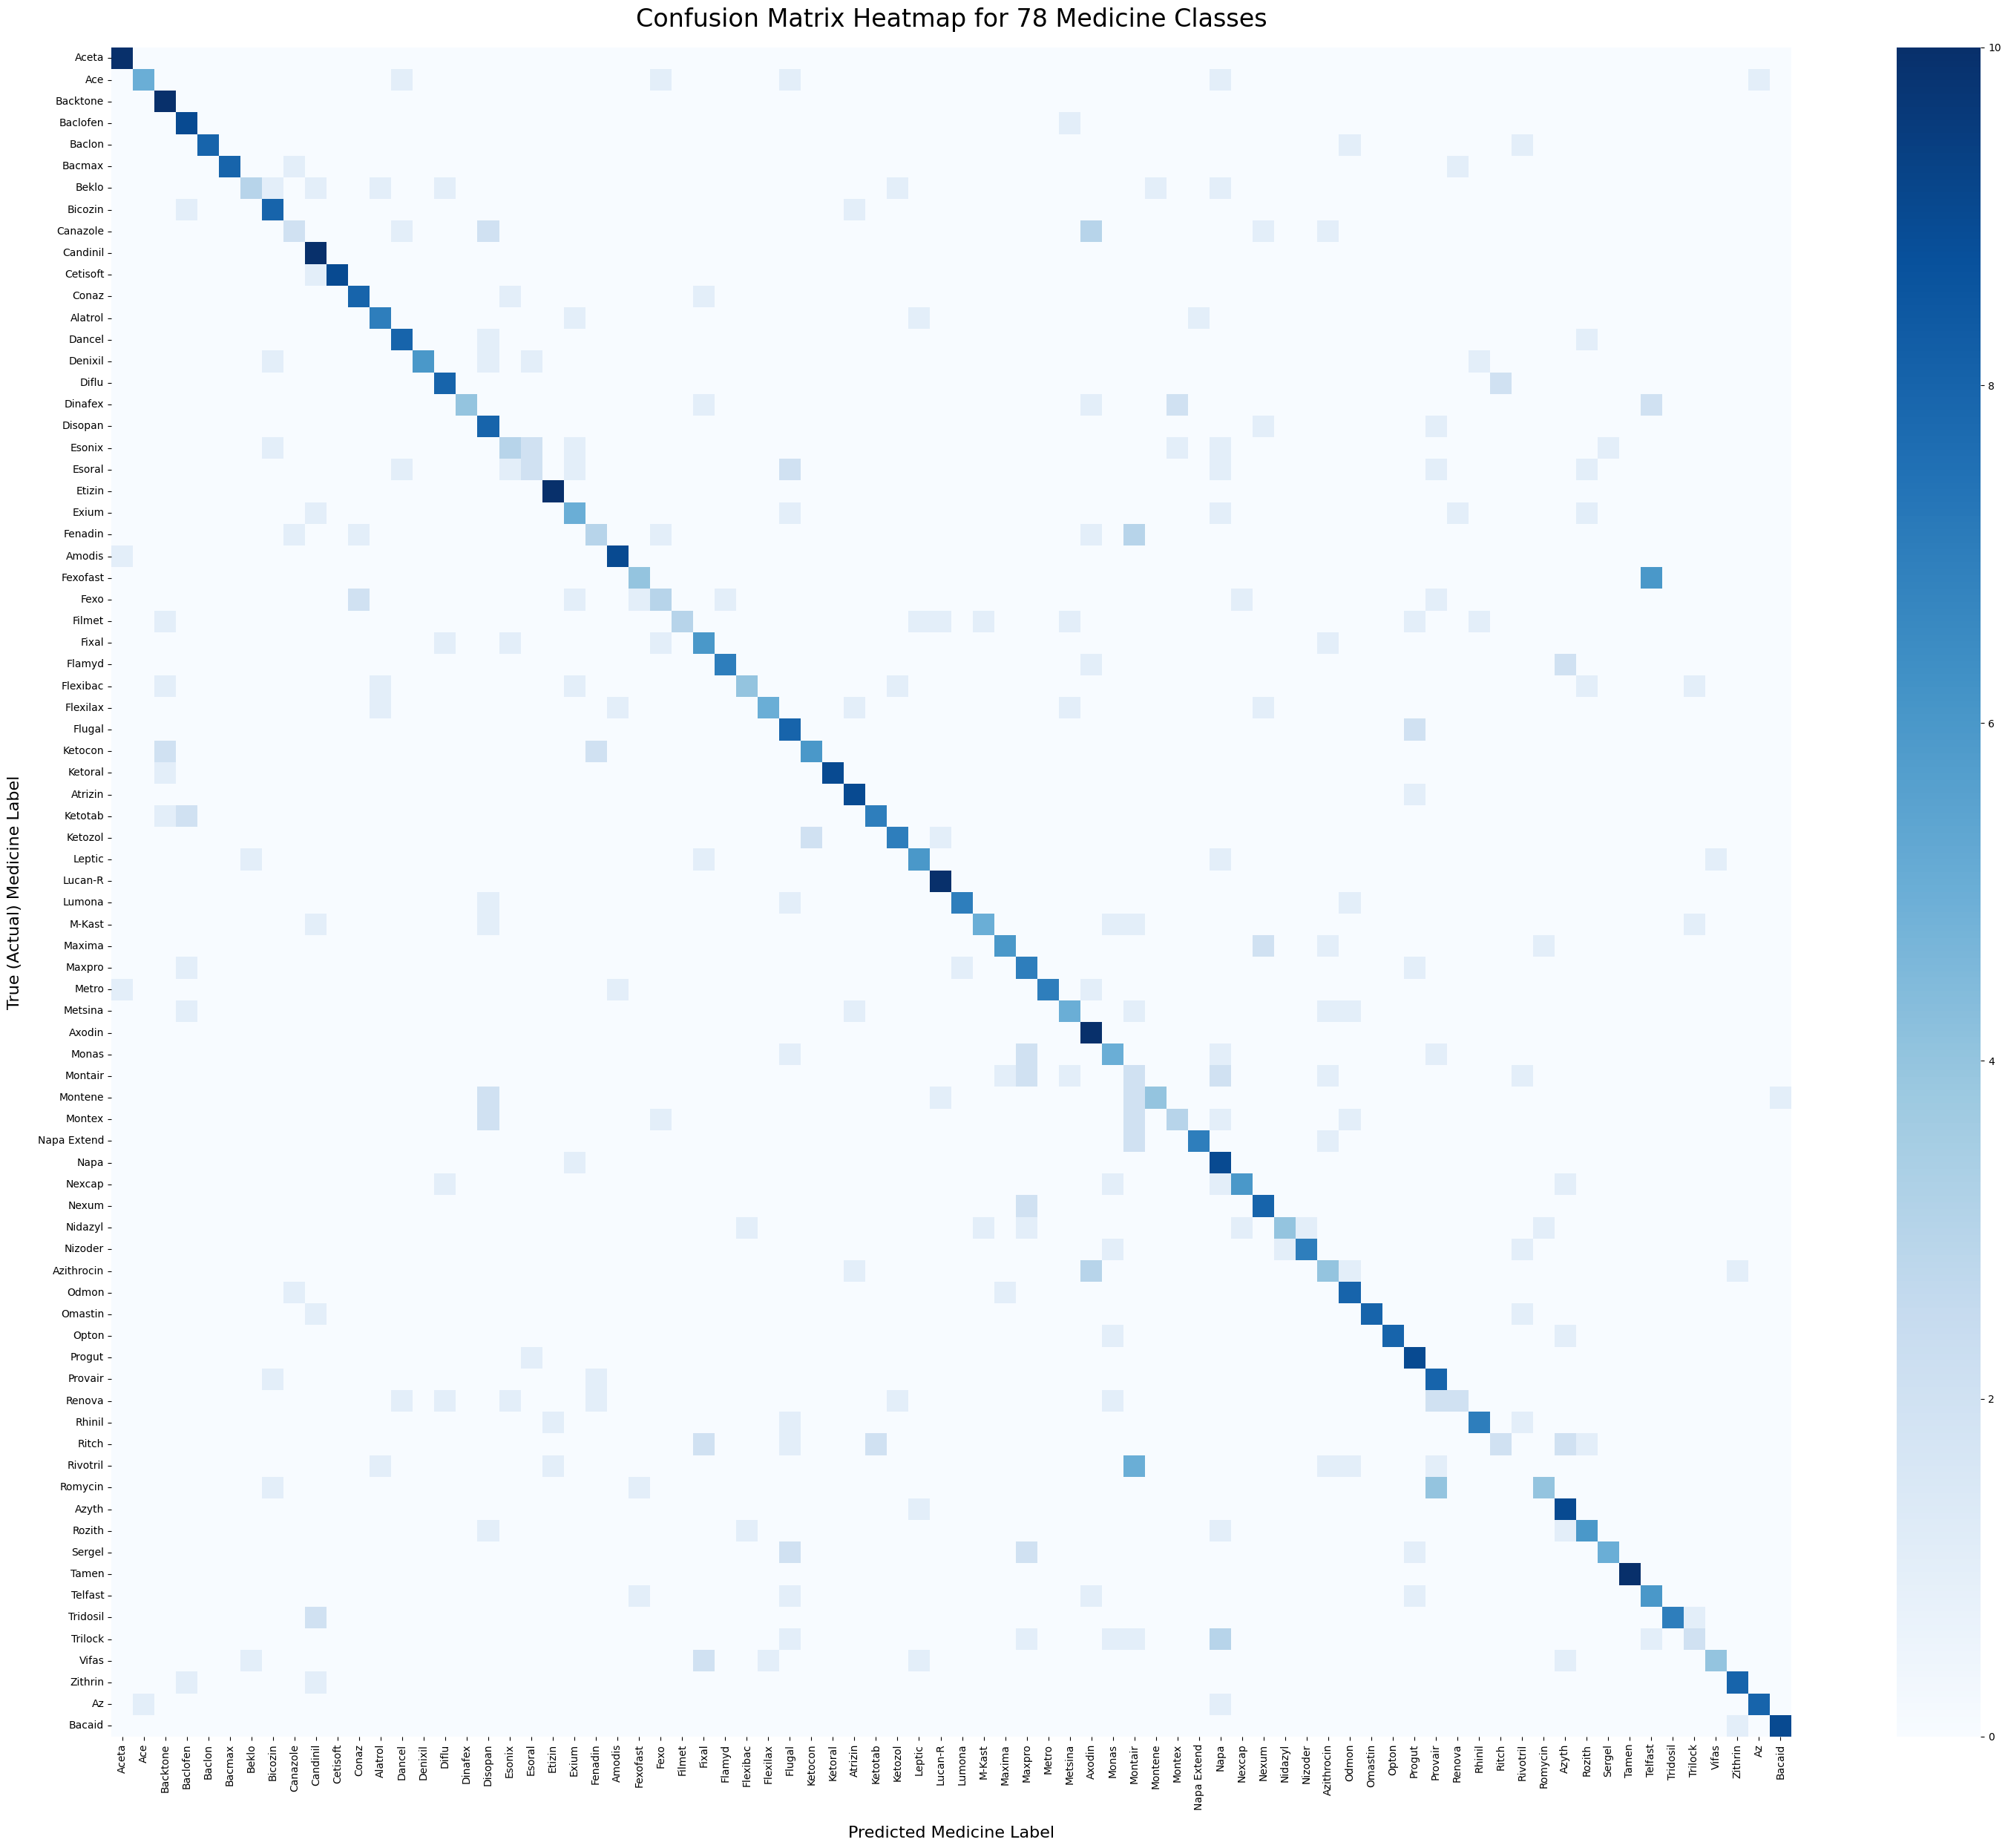

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Reset the test generator to ensure it starts from the first image
test_generator.reset()

# 2. Get predictions from the model
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

# 3. Create the reverse dictionary to map Numbers back to Medicine Names
# (Assumes 'drug_map' is your original JSON dictionary with Name: Number)
id_to_medicine = {str(value): key for key, value in drug_map.items()}

# 4. Extract the actual text labels in the exact order Keras sorted them
generator_classes = list(test_generator.class_indices.keys())
actual_medicine_names = [id_to_medicine.get(num, f"Unknown_{num}") for num in generator_classes]

# 5. Compute the mathematical confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# 6. Plot the massive 78x78 heatmap matrix
# We set a large figure size (30x25) so all 78 text labels are readable
plt.figure(figsize=(30, 25))
sns.heatmap(
    cm,
    annot=False,          # Turn off numbers inside boxes to avoid text overlapping
    cmap='Blues',         # Darker blue means more predictions landed there
    xticklabels=actual_medicine_names,
    yticklabels=actual_medicine_names
)

plt.title('Confusion Matrix Heatmap for 78 Medicine Classes', fontsize=24, pad=20)
plt.xlabel('Predicted Medicine Label', fontsize=16, labelpad=15)
plt.ylabel('True (Actual) Medicine Label', fontsize=16, labelpad=15)

# Rotate the axis labels so they don't overlap horizontally
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Save the matrix as a high-quality image file in Colab so you can download it for your report
plt.savefig('prescription_confusion_matrix.png', dpi=300)
plt.show()

Found 10 test images for drug: 'Telfast'


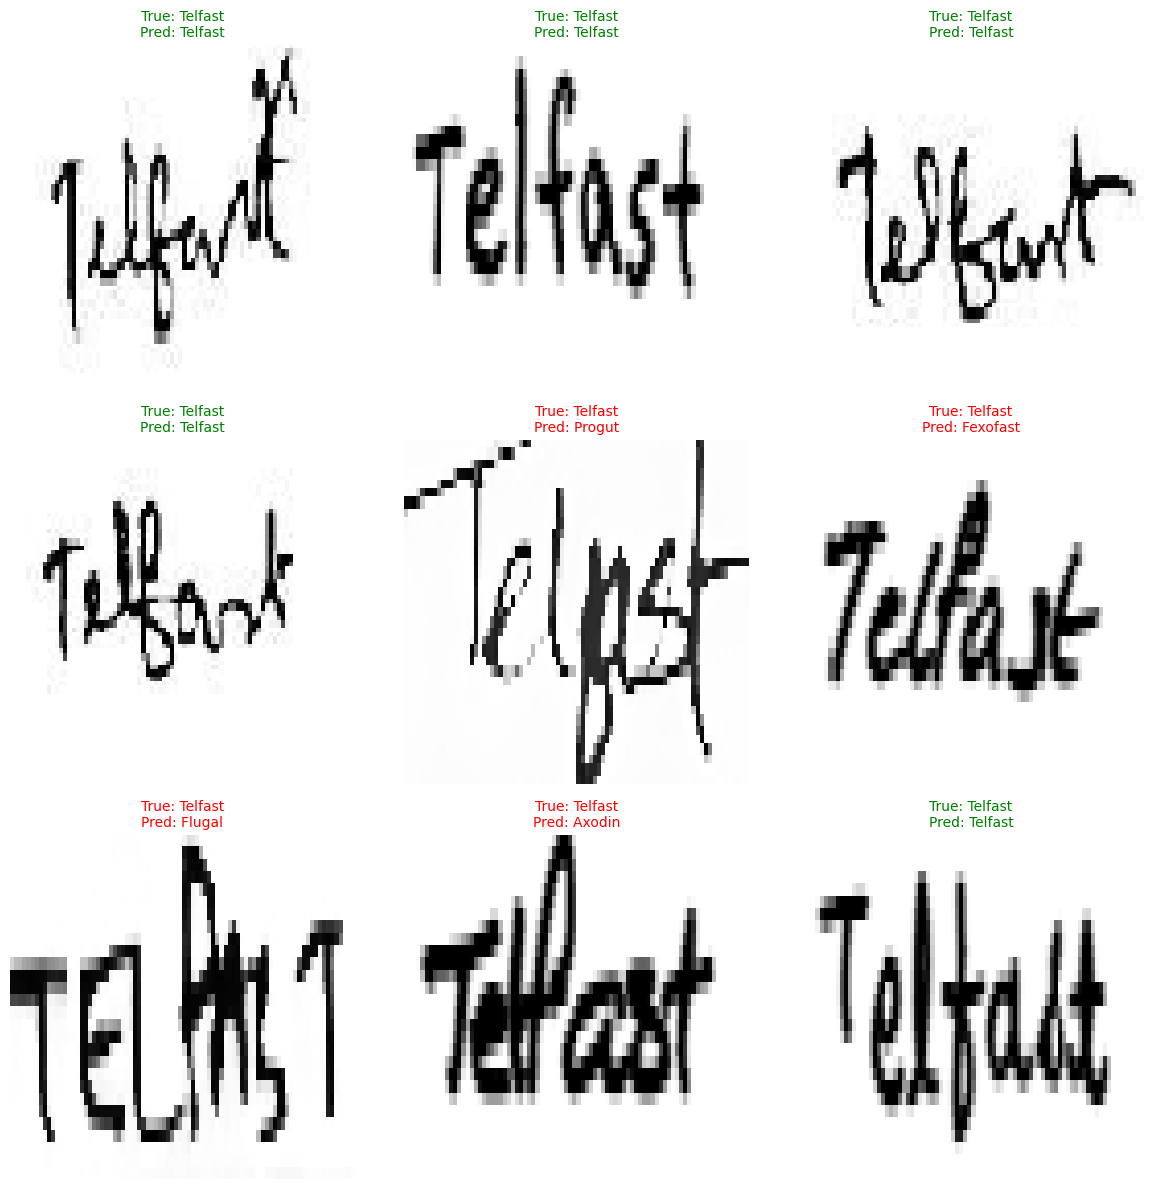

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

TARGET_DRUG_NAME = "Telfast"

# 1. Create mapping dictionaries between your text names and JSON numbers
name_to_id = drug_map # Your original JSON dictionary (Name -> Number)
id_to_name = {str(value): key for key, value in drug_map.items()}

# 2. Get the unique string ID Keras assigned to this drug number
# Keras matches folder/CSV strings, so we look up the internal class indexing
keras_class_indices = test_generator.class_indices # Maps string number to internal index (0-77)

# Check if the drug exists in your JSON mapping
if TARGET_DRUG_NAME not in name_to_id:
    print(f"Error: '{TARGET_DRUG_NAME}' not found in your mapping.json file. Check spelling!")
else:
    drug_num_str = str(name_to_id[TARGET_DRUG_NAME])

    # 3. Find rows in your test CSV that match this specific drug name/number
    # (Change 'MEDICINE_NAME' to whatever your CSV column is called)
    matching_rows = test_df[test_df['MEDICINE_NAME'].astype(str) == drug_num_str]

    print(f"Found {len(matching_rows)} test images for drug: '{TARGET_DRUG_NAME}'")

    if len(matching_rows) == 0:
        print("No samples of this drug are present in the Test folder split.")
    else:
        # Limit to display a maximum of 9 images in a 3x3 grid
        num_to_display = min(9, len(matching_rows))

        plt.figure(figsize=(12, 12))

        # Loop through the matching rows and extract images
        for i in range(num_to_display):
            row = matching_rows.iloc[i]
            img_name = row['IMAGE'] # Your CSV image filename column

            # Construct absolute path to image
            img_path = os.path.join("/content/dataset/data/processed/test/images", img_name)

            # Read image in Grayscale (matching training conditions)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                # 4. Preprocess image to match what the CNN expects
                img_resized = cv2.resize(img, (84, 84))
                img_normalized = img_resized / 255.0               # Scale pixels to [0,1]
                img_input = np.expand_dims(img_normalized, axis=-1) # Add channel dim -> (84, 84, 1)
                img_batch = np.expand_dims(img_input, axis=0)       # Add batch dim -> (1, 84, 84, 1)

                # 5. Make the Prediction
                pred_prob = model.predict(img_batch, verbose=0)
                pred_internal_idx = np.argmax(pred_prob, axis=1)[0]

                # Look up what text name matches the internal index Keras chose
                pred_num_str = [k for k, v in keras_class_indices.items() if v == pred_internal_idx][0]
                pred_drug_name = id_to_name.get(pred_num_str, f"Unknown_{pred_num_str}")

                # 6. Plot the results
                plt.subplot(3, 3, i + 1)
                plt.imshow(img_resized, cmap='gray')

                color = 'green' if pred_drug_name == TARGET_DRUG_NAME else 'red'
                plt.title(f"True: {TARGET_DRUG_NAME}\nPred: {pred_drug_name}", color=color, fontsize=10)
                plt.axis('off')
            else:
                print(f"Could not read image file: {img_path}")

        plt.tight_layout()
        plt.show()